In [22]:
import astropy.io.fits as fits
import astropy.units as u
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import aplpy
import astropy.wcs.wcs as wcs
import glob
import os
import pandas as pd

from create_figs import create_m0_map
from create_figs import mark_sources, cut_fig, create_fig

import warnings
warnings.filterwarnings("ignore")

In [23]:
source_info = pd.read_csv("../data/output/source_info.csv")
source_info.set_index('Main', inplace=True)

INFO: Auto-setting vmin to -7.188e-03 [aplpy.core]
INFO: Auto-setting vmax to  7.978e-02 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  6.845e-02 [aplpy.core]


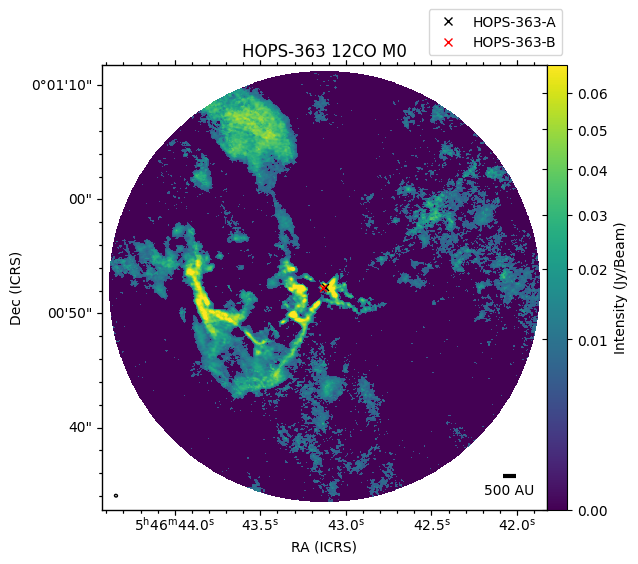

In [24]:
target_name = "HOPS-363"
output_path = f"../results/m0_maps/{target_name}_m0.pdf"
file = "/Volumes/Alpha/Research/data/hops-363/hops-363__s15__12co.fits"

target_info = source_info.loc[target_name]

hdulist = fits.open(file)
hdu = hdulist[0]

# extract center coords
center_ra = hdu.header['OBSRA']
center_dec = hdu.header['OBSDEC']

# set center and size of cutout
center = SkyCoord(center_ra, center_dec, unit=u.degree)
size = np.array([39, 39]) * u.arcsecond

# create map
channel_idx = np.r_[92:94, 107:110]

fig = create_m0_map(hdu, center, size, channel_idx, sigma=3, distance=target_info['Dis'].iloc[0])
fig.set_title(f"{target_name} 12CO M0")
fig.show_colorscale(cmap='viridis', stretch='sqrt')

# add a marker at each source
mark_sources(fig, target_info)

# fig.savefig(output_path)

INFO: Auto-setting vmin to -2.077e-02 [aplpy.core]
INFO: Auto-setting vmax to  2.305e-01 [aplpy.core]
INFO: Auto-setting vmin to  0.000e+00 [aplpy.core]
INFO: Auto-setting vmax to  2.029e-01 [aplpy.core]


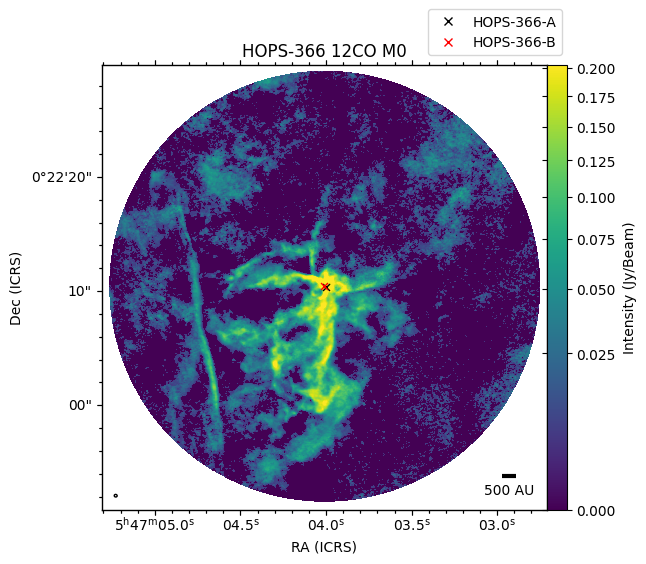

In [25]:
target_name = "HOPS-366"
output_path = f"../results/m0_maps/{target_name}_m0.png"
file = "/Volumes/Alpha/Research/data/hops-366/hops-366__s15__12co.fits"

target_info = source_info.loc[target_name]

hdulist = fits.open(file)
hdu = hdulist[0]

# extract center coords
center_ra = hdu.header['OBSRA']
center_dec = hdu.header['OBSDEC']

# set center and size of cutout
center = SkyCoord(center_ra, center_dec, unit=u.degree)
size = np.array([39, 39]) * u.arcsecond

# create map
channel_idx = np.r_[80:87, 112:120]
fig = create_m0_map(hdu, center, size, channel_idx, sigma=3, distance=target_info.iloc[0]['Dis'])
fig.set_title(f"{target_name} 12CO M0")
fig.show_colorscale(cmap='viridis', stretch='sqrt')

# add a marker at each source
mark_sources(fig, target_info)

# fig.savefig(output_path)

INFO: Auto-setting vmin to -1.921e-02 [aplpy.core]
INFO: Auto-setting vmax to  2.132e-01 [aplpy.core]
INFO: Auto-setting vmax to  2.036e-01 [aplpy.core]


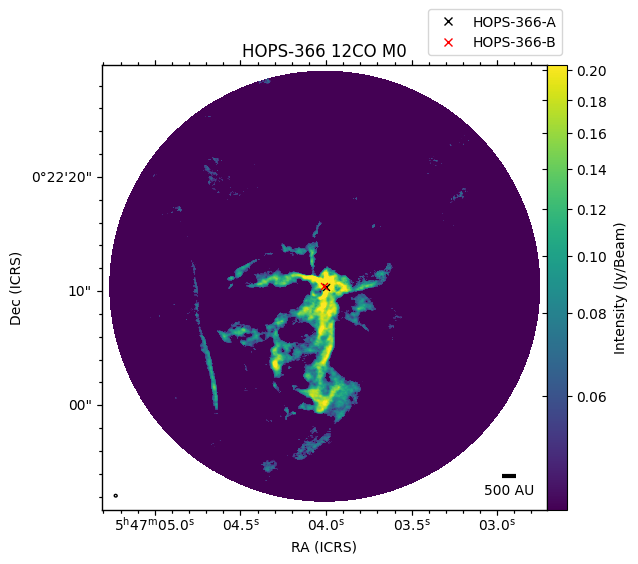

In [26]:
# create map
channel_idx = np.r_[80:87, 112:120]
fig = create_m0_map(hdu, center, size, channel_idx, sigma=3, distance=target_info.iloc[0]['Dis'])
fig.set_title(f"{target_name} 12CO M0")
fig.show_colorscale(cmap='viridis', stretch='sqrt',vmin=0.05)

# add a marker at each source
mark_sources(fig, target_info)